In [1]:
import os
from pathlib import Path
import kagglehub

data_dir = Path.cwd() / "data"
data_dir.mkdir(parents=True, exist_ok=True)

# Force kagglehub cache path to project data folder
os.environ["KAGGLEHUB_CACHE"] = str(data_dir)

path = kagglehub.dataset_download("alexteboul/diabetes-health-indicators-dataset")
print("Path to dataset files:", path)

c:\Users\cocon\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 6.03M/6.03M [00:00<00:00, 7.14MB/s]

Extracting files...


Path to dataset files: c:\Users\cocon\Desktop\data\datasets\alexteboul\diabetes-health-indicators-dataset\versions\1


# Data Explore

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

csv_path = Path(path) / "diabetes_binary_health_indicators_BRFSS2015.csv"
data = pd.read_csv(csv_path)
data.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [4]:
data.shape

(253680, 22)

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

In [6]:
data.describe()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


# Data Preprocess

## check Null values

In [7]:
data.isnull().sum()

Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

## Check The Outliers

In [ ]:
# TBD

## Check and drop dublicated data

In [8]:
data.duplicated().sum()

np.int64(24206)

In [9]:
data.drop_duplicates(inplace = True)

In [10]:
data.duplicated().sum()

np.int64(0)

In [11]:
data.shape

(229474, 22)

# EDA

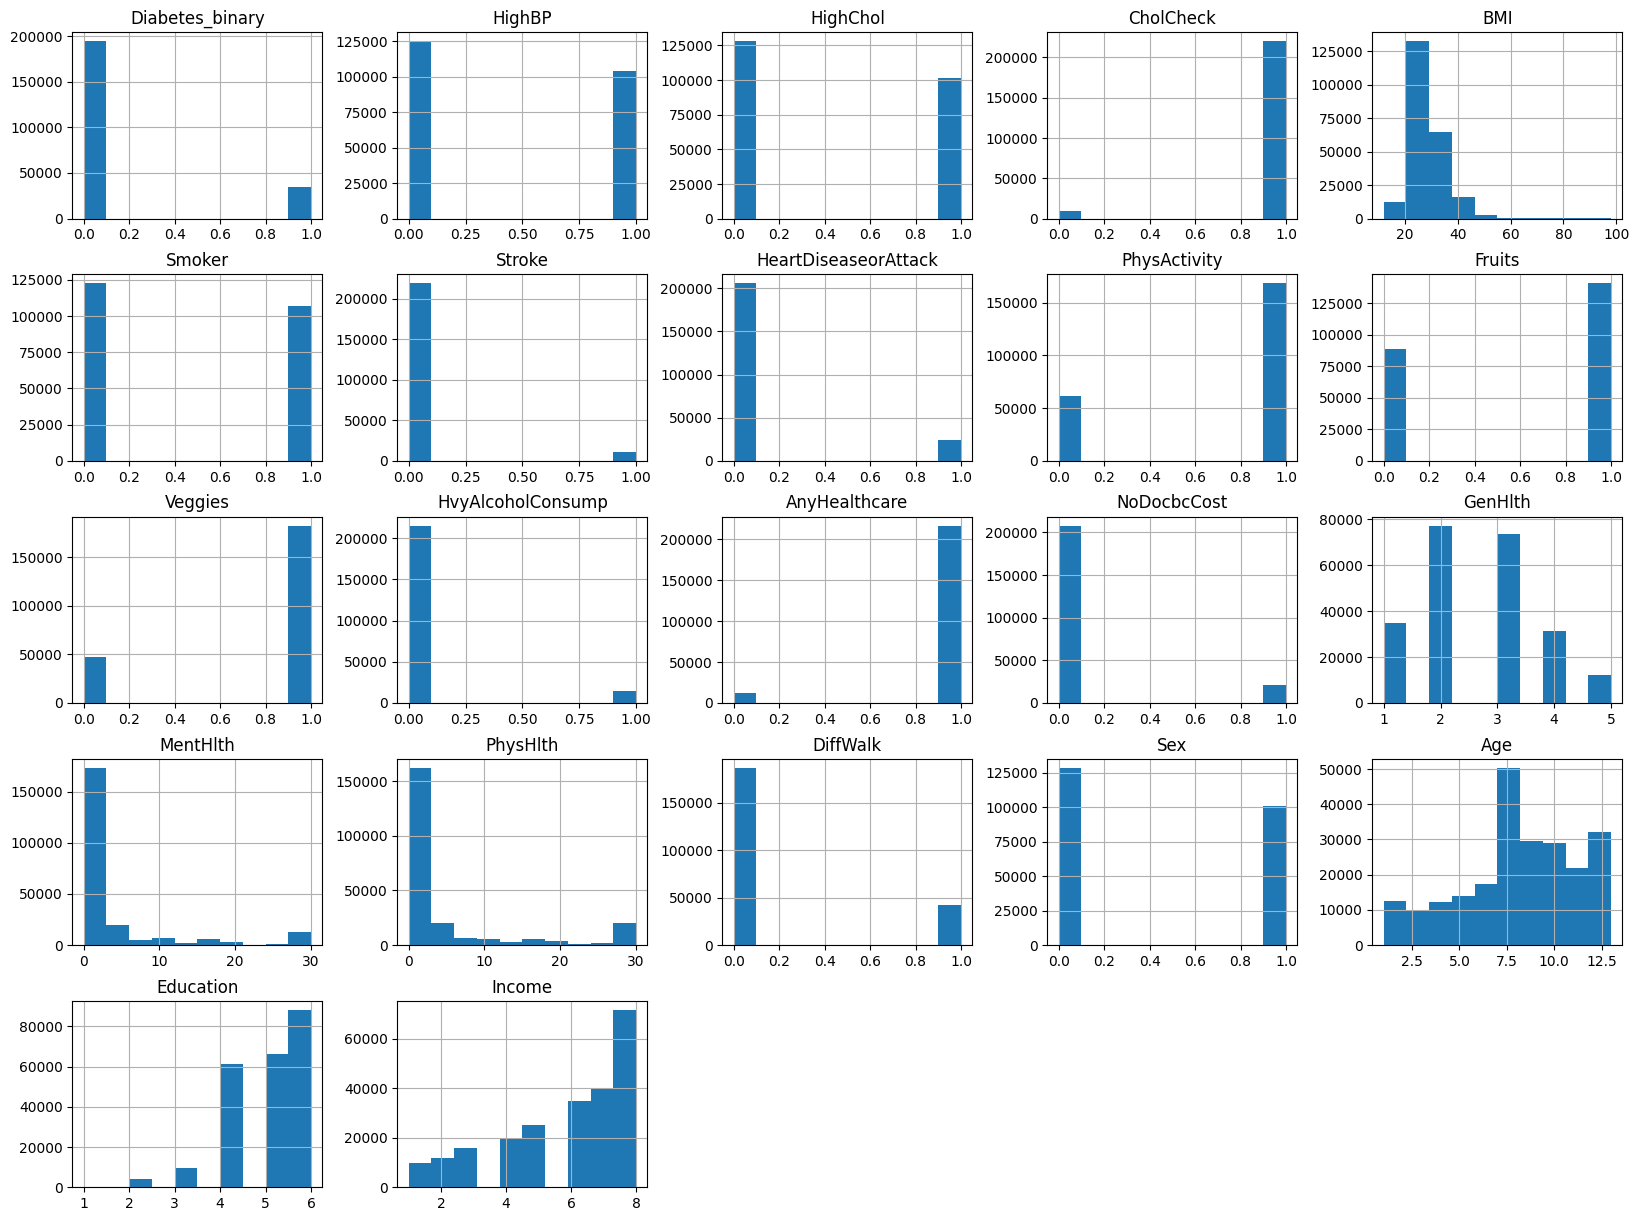

In [12]:
data.hist(figsize=(20,15));

Text(0.5, 1.0, 'correlation of feature')

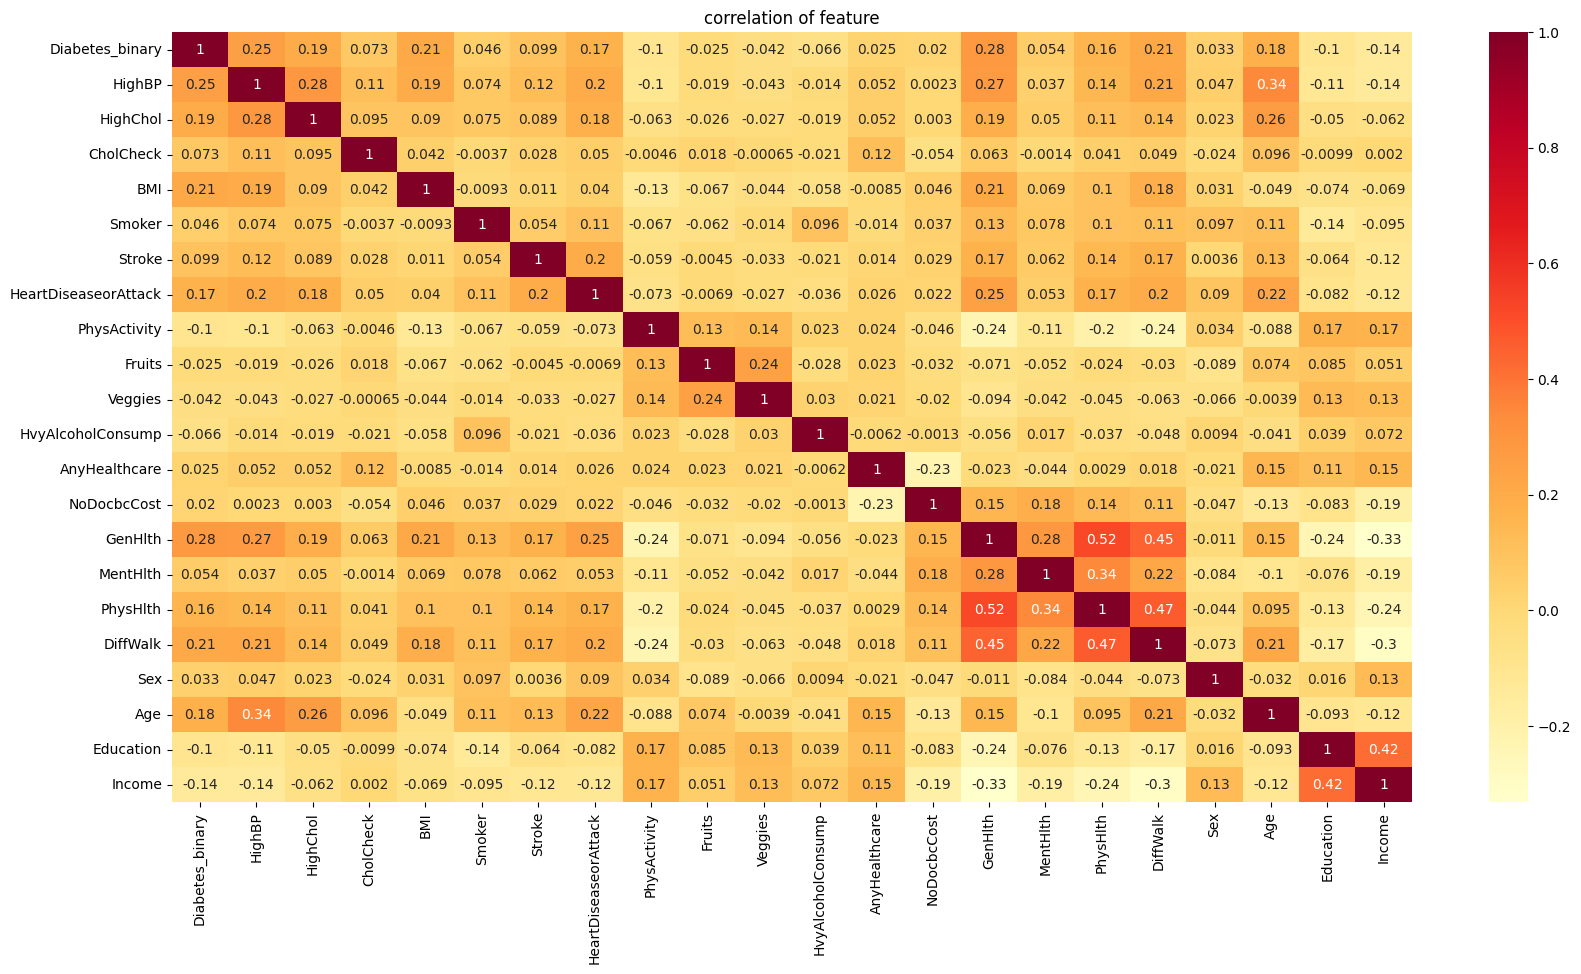

In [13]:
plt.figure(figsize = (20,10))
sns.heatmap(data.corr(),annot=True,cmap ='YlOrRd' )
plt.title("correlation of feature")

### Correlation heatmap show relation between columns:

(GenHlth ,PhysHlth ),(PhysHlth , DiffWalk),(GenHlth ,DiffWalk )are highly correleted with each other => positive relation

(GenHlth ,Income ) , (DiffWalk , Income) are highly correleted with each other => Nagative relation



## Correlation with Diabetes_binary

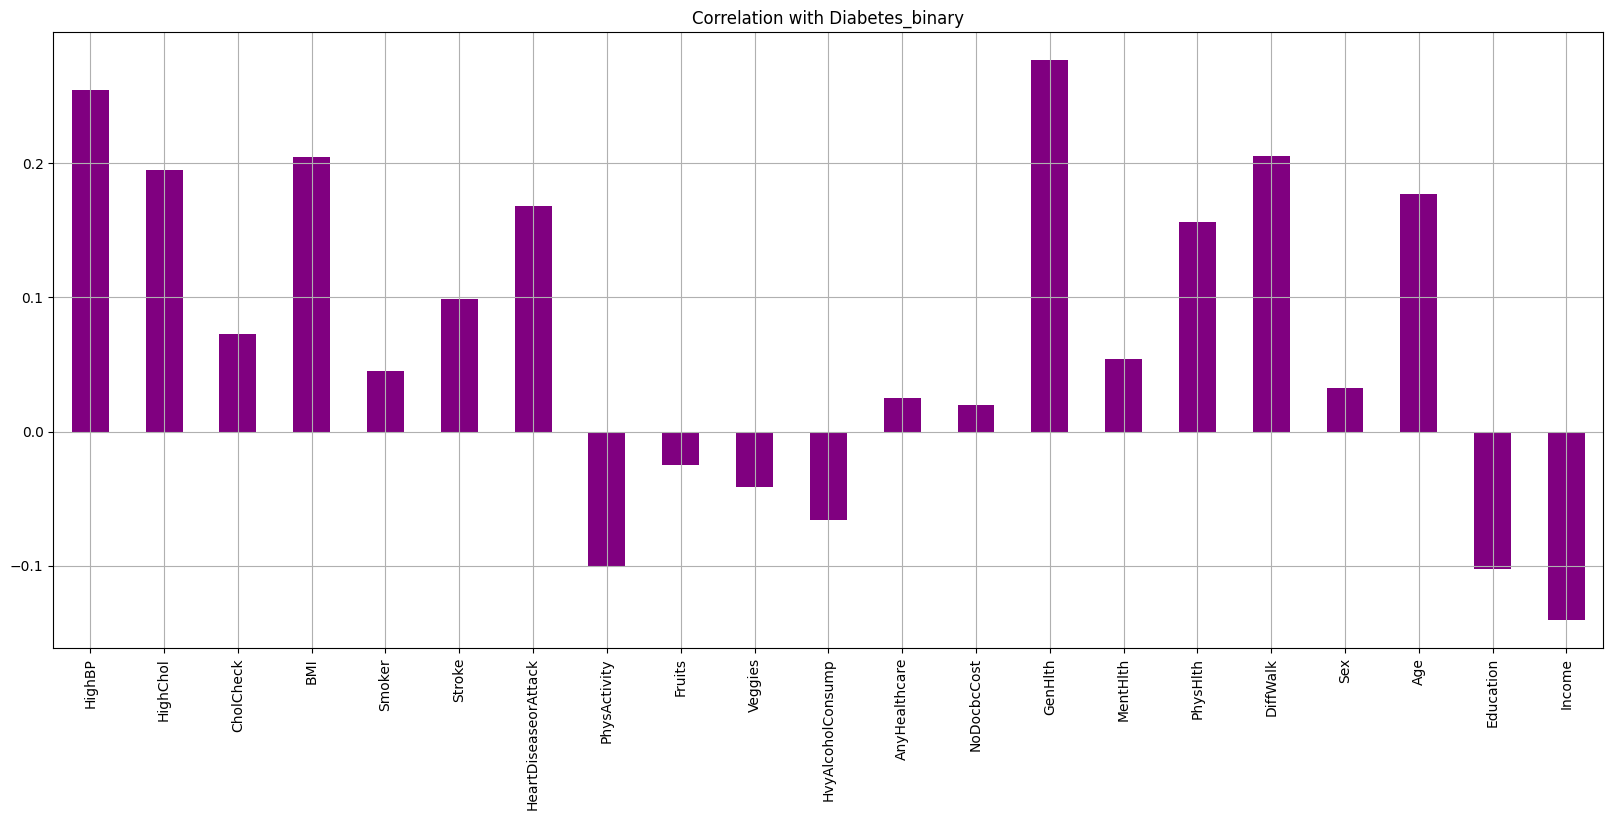

In [14]:
data.drop('Diabetes_binary', axis=1).corrwith(data.Diabetes_binary).plot(kind='bar', grid=True, figsize=(20, 8)
, title="Correlation with Diabetes_binary",color="Purple");

Diabetes_binary's relation with other columns Through bar Graph Result:


HighBP , HighChol , BMI , Stroke , HeartDiseaseorAttack , GenHlth , PhysHlth , DiffWalk, Age ,  //PhysActivity ,Education , and Income have a significant correlation with Diabetes_binary.

In [15]:
cols = ['HighBP', 'HighChol', 'BMI', 'Stroke', 'HeartDiseaseorAttack',  'GenHlth',
       'PhysHlth',  'DiffWalk','Age','PhysActivity','Education','Income']

In [16]:
def get_percentage_table(data, column_name):
    result = pd.crosstab(data[column_name], data['Diabetes_binary'], normalize='index')
    return result * 100

In [17]:
col1=['HighBP', 'HighChol']

C:\Users\cocon\AppData\Local\Temp\ipykernel_38924\3365854041.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


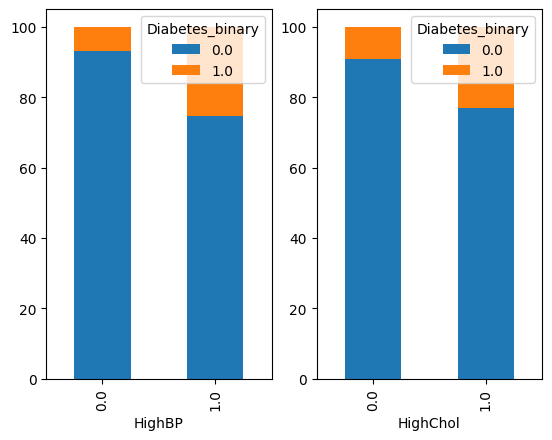

In [18]:
fig, ax = plt.subplots(1, 2)
axe = ax.ravel()

c = len(col1)

for i in range(c):
    get_percentage_table(data, col1[i]).plot(kind='bar',stacked=True, ax=axe[i])
    axe[i].set_xlabel(col1[i])

fig.show()

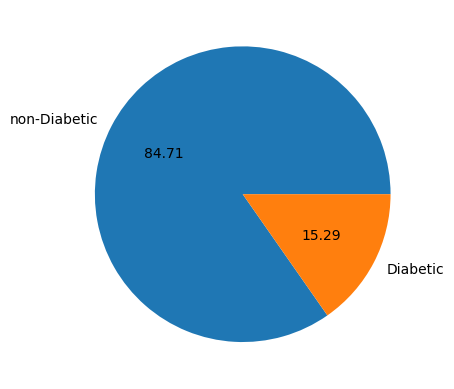

In [19]:

labels=["non-Diabetic","Diabetic"]

plt.pie(data["Diabetes_binary"].value_counts() , labels =labels ,autopct='%.02f' );

We can see that healthy people is more than people with diabetes

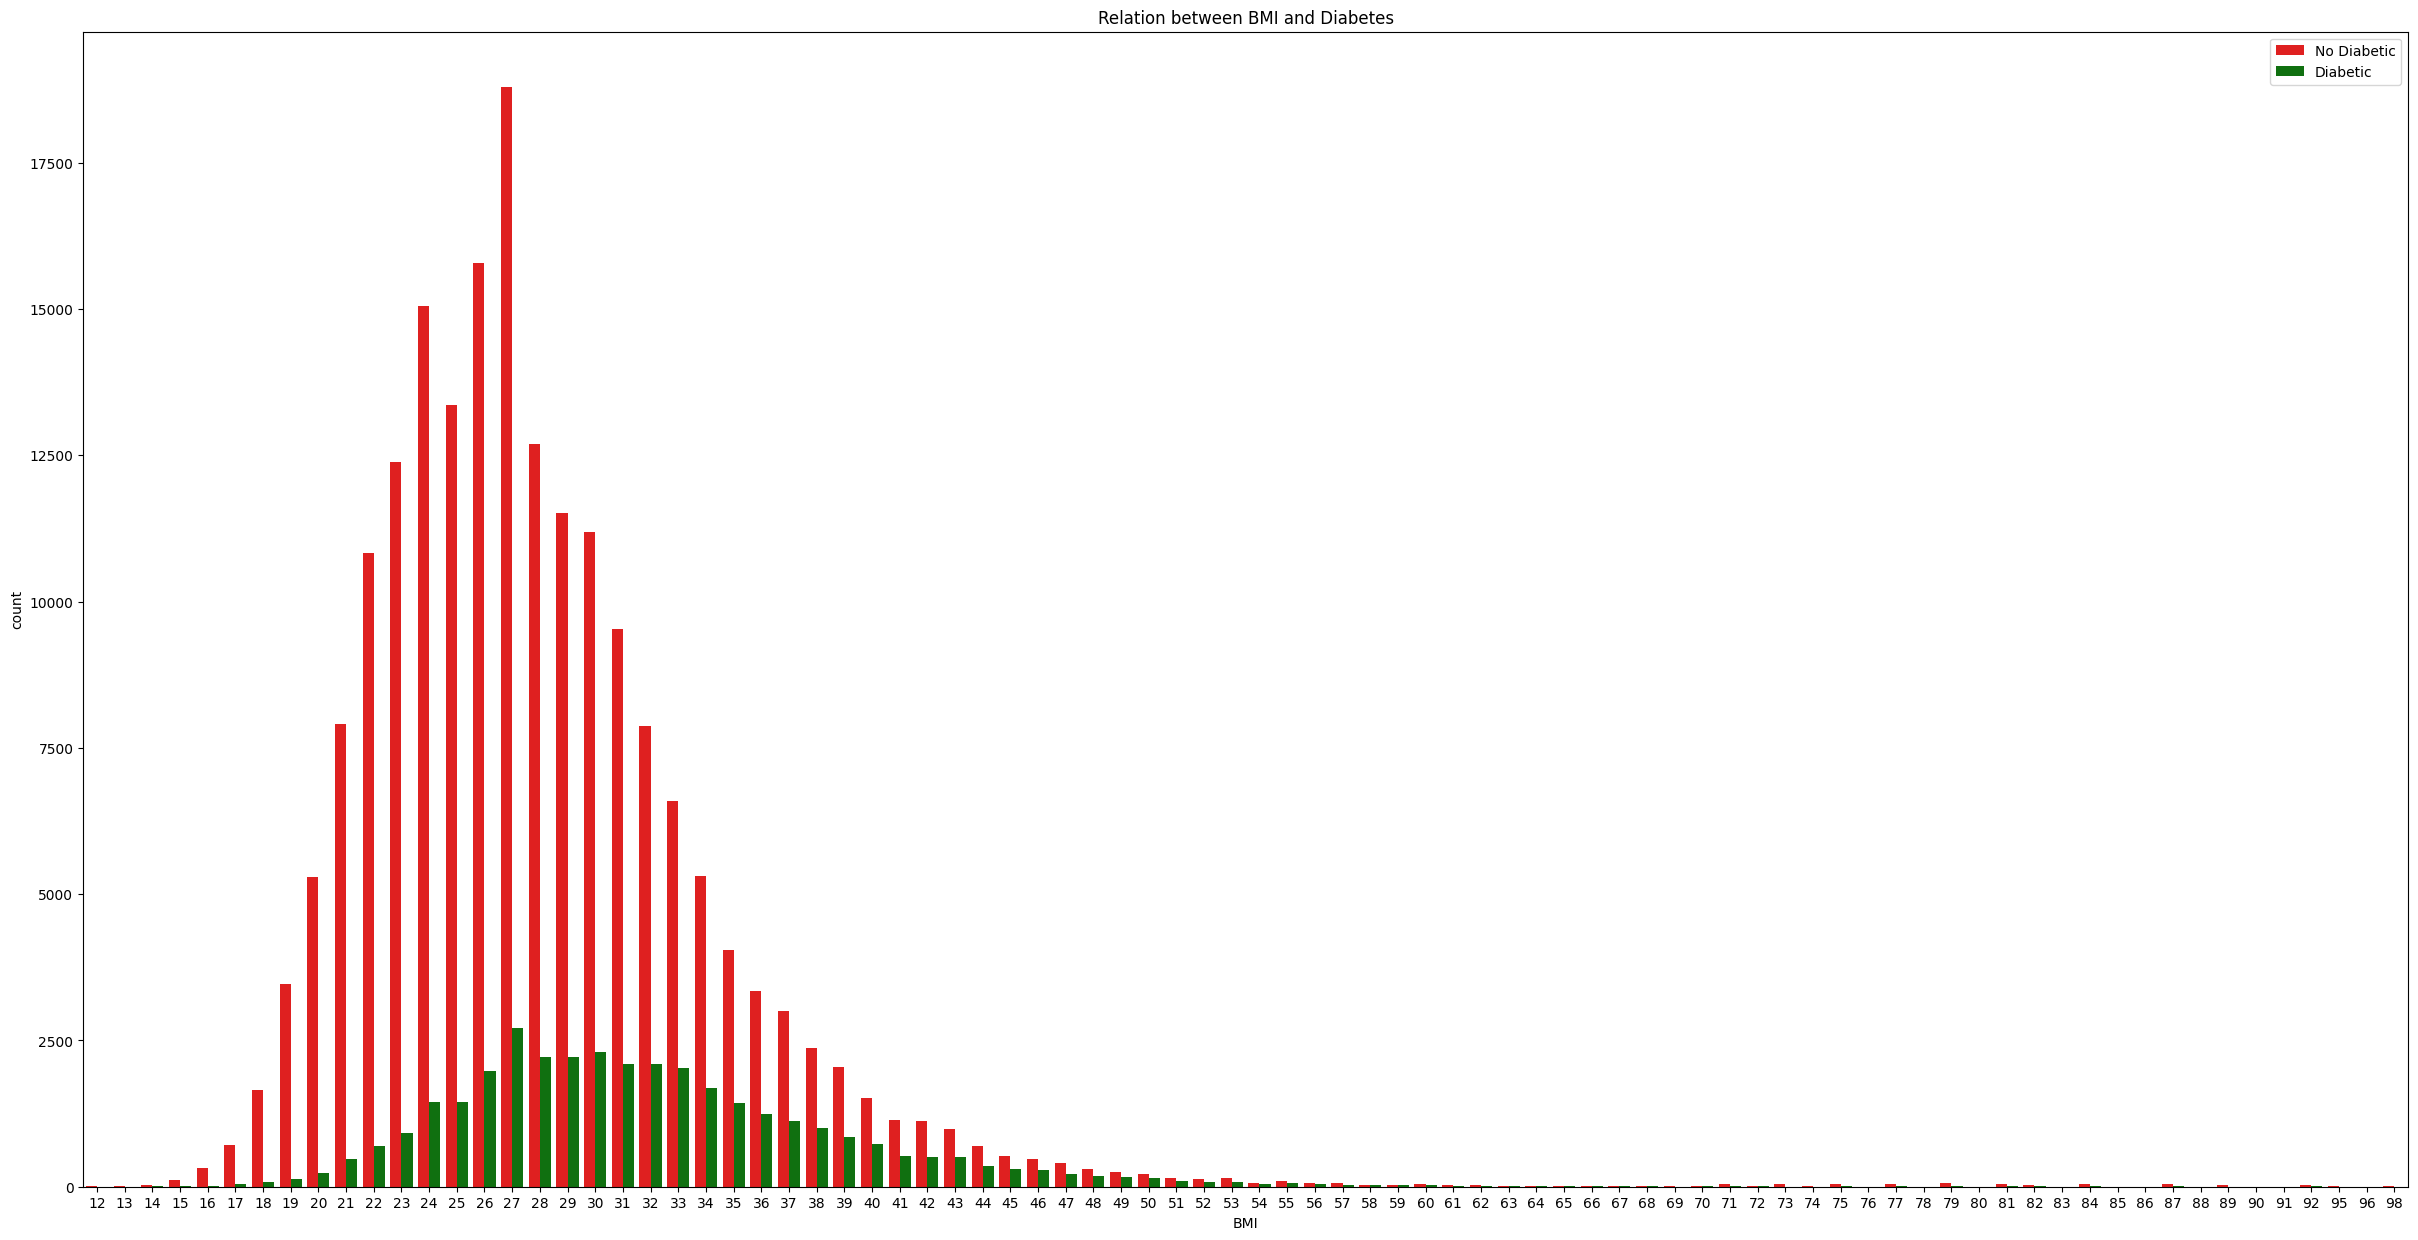

In [20]:
plt.figure(figsize=(30, 15))
data["BMI"] = data["BMI"].astype(int)
sns.countplot(
      data=data,
      x="BMI",
      hue="Diabetes_binary",
      palette={0: "r", 1: "g"}
  )

plt.title("Relation between BMI and Diabetes")
plt.legend(title="", labels=["No Diabetic", "Diabetic"])

As we can see people range between 24-33 BMI have more likely to have Diabetic.

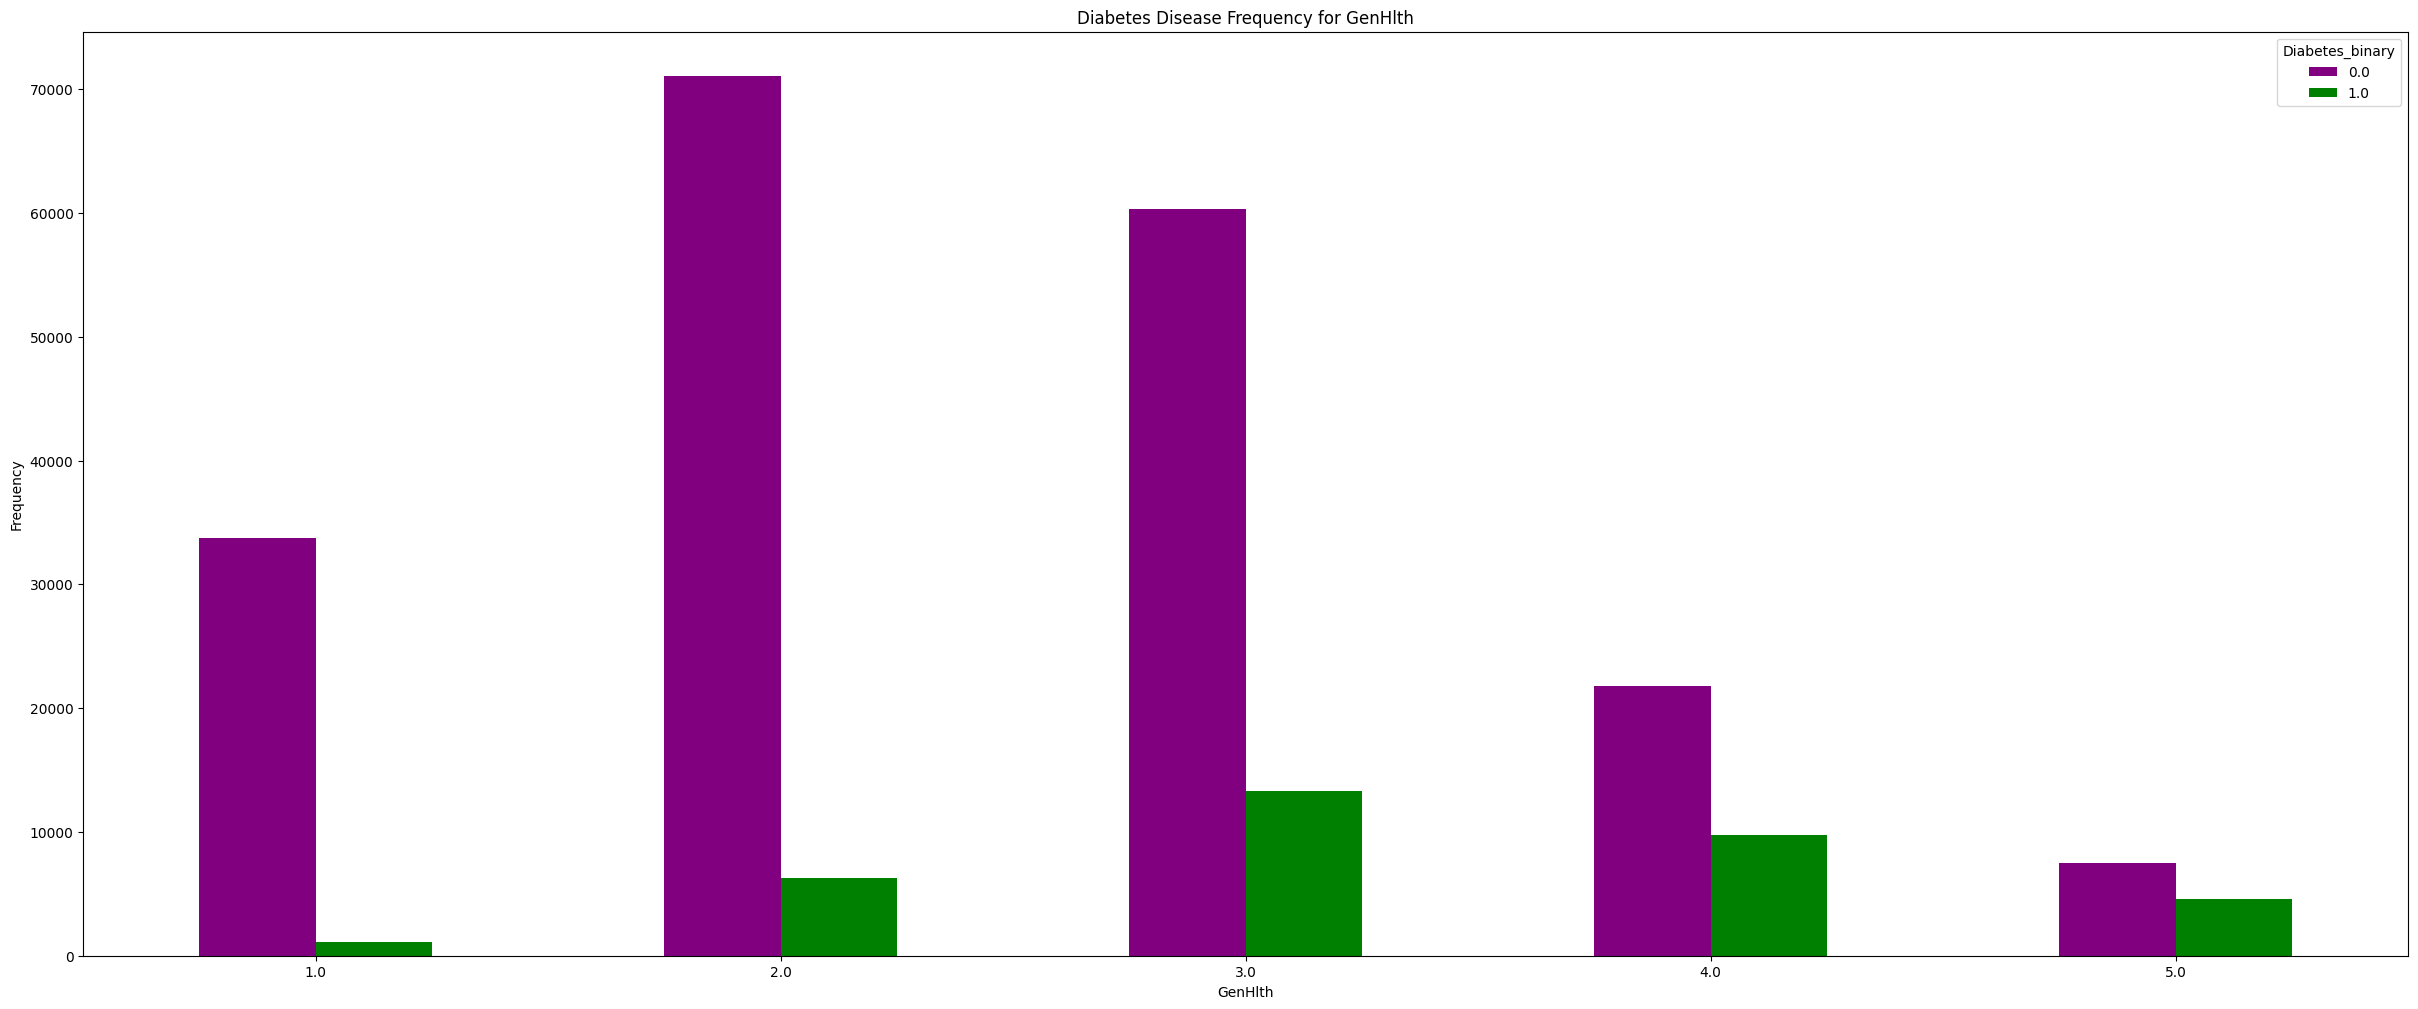

In [21]:
pd.crosstab(data.GenHlth,data.Diabetes_binary).plot(kind="bar",figsize=(30,12),color=['Purple', 'Green' ])
plt.title('Diabetes Disease Frequency for GenHlth')
plt.xlabel('GenHlth')
plt.xticks(rotation=0)
plt.ylabel('Frequency')
plt.show()

INTERESTING! Most Diabetic people would rate their general health as rather good while non-diabetic people mostly think they do not have good general health.

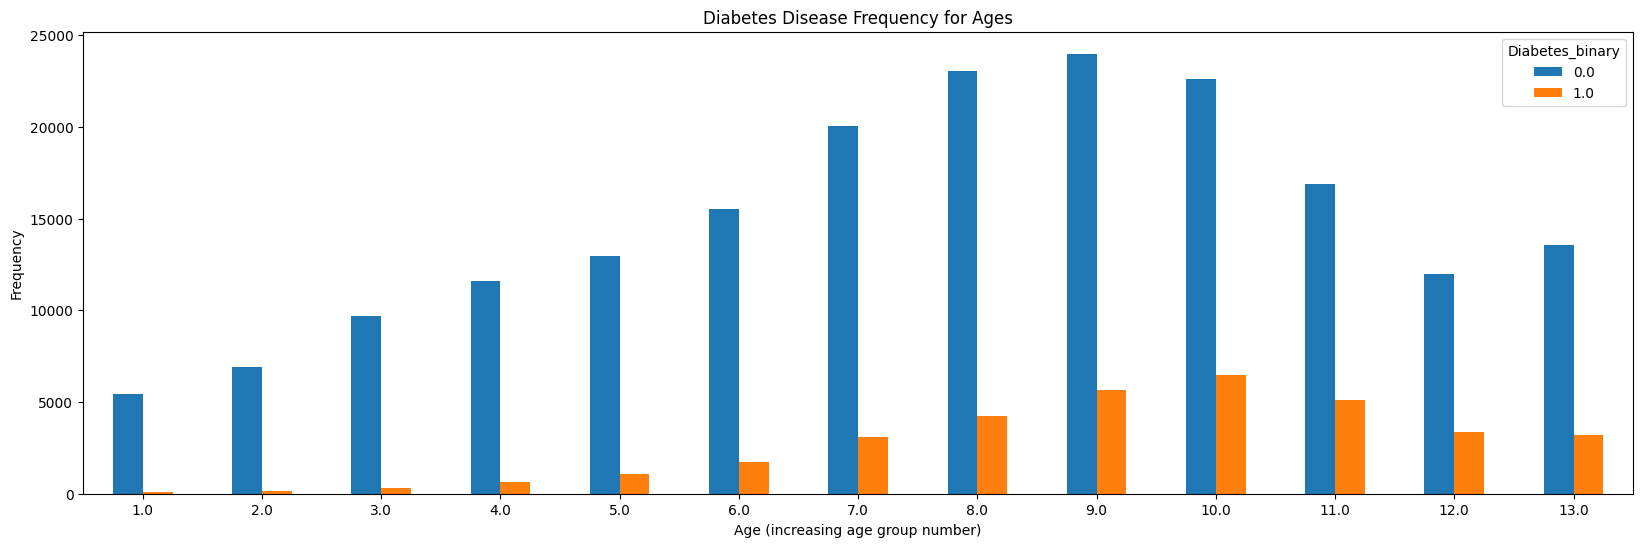

In [22]:
pd.crosstab(data.Age,data.Diabetes_binary).plot(kind="bar",figsize=(20,6))
plt.title('Diabetes Disease Frequency for Ages')
plt.xlabel('Age (increasing age group number)')
plt.xticks(rotation=0)
plt.ylabel('Frequency')
plt.show()

We know that as the age increases, the chances of diabetes also commonly increases. From above we can say, the median of the age of diabetic people is greater than that of non-diabetic people.

C:\Users\cocon\AppData\Local\Temp\ipykernel_38924\3993022065.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data.Education[data.Diabetes_binary == 0], color="y", label="No Diabetic" )
C:\Users\cocon\AppData\Local\Temp\ipykernel_38924\3993022065.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.dis

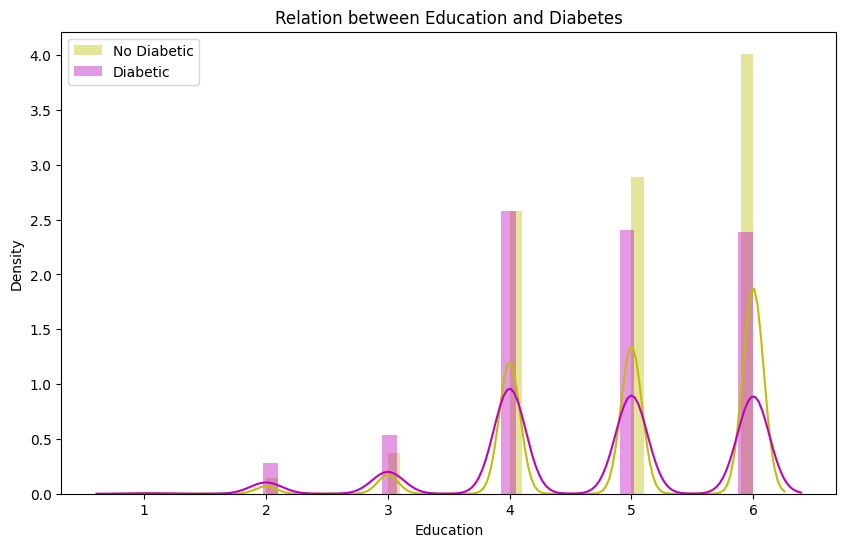

In [23]:
plt.figure(figsize=(10,6))


sns.distplot(data.Education[data.Diabetes_binary == 0], color="y", label="No Diabetic" )
sns.distplot(data.Education[data.Diabetes_binary == 1], color="m", label="Diabetic" )
plt.title("Relation between Education and Diabetes")

plt.legend()

We can see that people with higher education will less likely have diabetes, corresponding to the common sense that well-educated people would care more about their diets,lifestyles, and health,etc.

Text(0.5, 1.0, 'Relation between Income and Diabetes')

<Figure size 2000x1000 with 0 Axes>

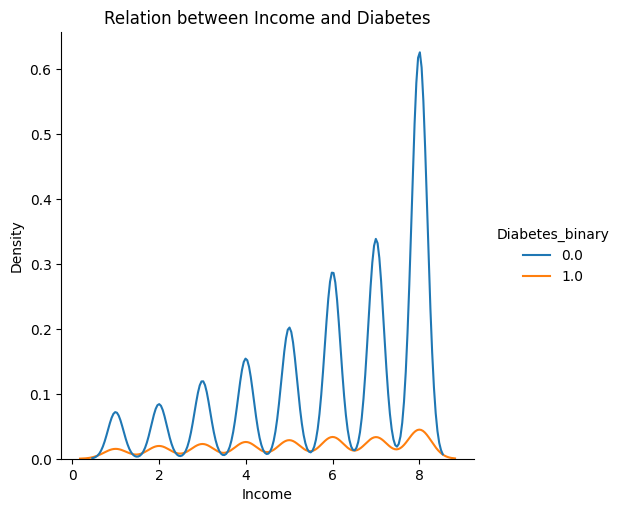

In [24]:
plt.figure(figsize=(20,10))

sns.displot(data=data, x="Income", hue="Diabetes_binary", kind="kde")
plt.title("Relation between Income and Diabetes")

We can also see that people with more income will have fewer risks for diabetes, corresponding to the knowledge that rich people will care more about their health.

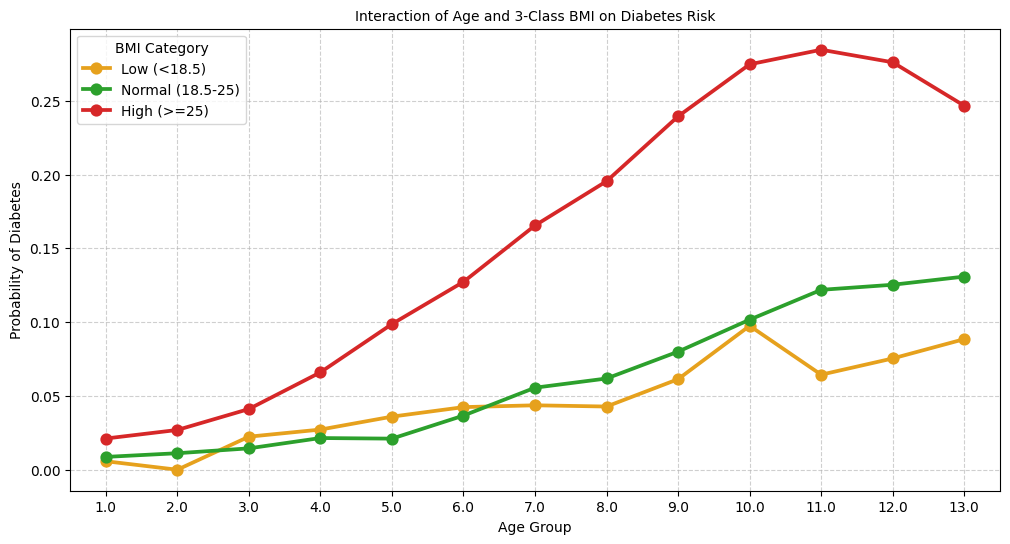

In [25]:
data['BMI_cat_3'] = pd.cut(data['BMI'], 
                           bins=[0, 18.5, 25, 100], 
                           labels=['Low (<18.5)', 'Normal (18.5-25)', 'High (>=25)'])

plt.figure(figsize=(12, 6))
sns.pointplot(data=data, x='Age', y='Diabetes_binary', hue='BMI_cat_3', 
              errorbar=None, palette=["#E6A11D", "#2CA02C", "#D62728"])

plt.title('Interaction of Age and 3-Class BMI on Diabetes Risk', fontsize=10)
plt.xlabel('Age Group', fontsize=10)
plt.ylabel('Probability of Diabetes', fontsize=10)
plt.legend(title='BMI Category')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Time-Acceleration Effect

The red line, representing the 'High BMI' category, demonstrates how being overweight dramatically accelerates disease onset. An individual with a high BMI in their early 30s, exhibits the exact same diabetes probability as a normal-weight person, shown by the green line, in their late 60s. Ultimately, this highlights high BMI as a massive risk multiplier, effectively aging a patient's metabolic health by over 30 years.

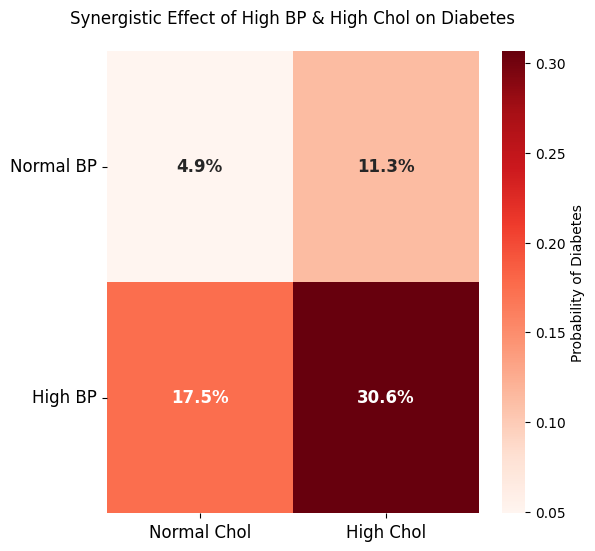

In [26]:
metabolic_pivot = data.pivot_table(
    values='Diabetes_binary', 
    index='HighBP', 
    columns='HighChol', 
    aggfunc='mean'
)

metabolic_pivot.index = ['Normal BP', 'High BP']
metabolic_pivot.columns = ['Normal Chol', 'High Chol']

plt.figure(figsize=(6, 6))
sns.heatmap(metabolic_pivot, annot=True, fmt=".1%", cmap="Reds", 
            cbar_kws={'label': 'Probability of Diabetes'}, 
            annot_kws={"size": 12, "weight": "bold"})

plt.title('Synergistic Effect of High BP & High Chol on Diabetes', fontsize=12, pad=20)
plt.yticks(rotation=0, fontsize=12)
plt.xticks(fontsize=12)
plt.show()

synergistic effect between high blood pressure and high cholesterol on diabetes risk

Starting at the top-left, the baseline risk for patients with normal levels is only 4.9%. Having just one of these conditions raises the risk to 11.3% and 17.5% respectively. However, for patients suffering from both conditions, the probability skyrockets to 30.6%. This is not a simple linear addition of risks—which would theoretically only reach about 24%, it is a severe multiplier effect. Clinically, this emphasizes that preventing the second cardiovascular condition is absolutely critical to halting the onset of diabetes.

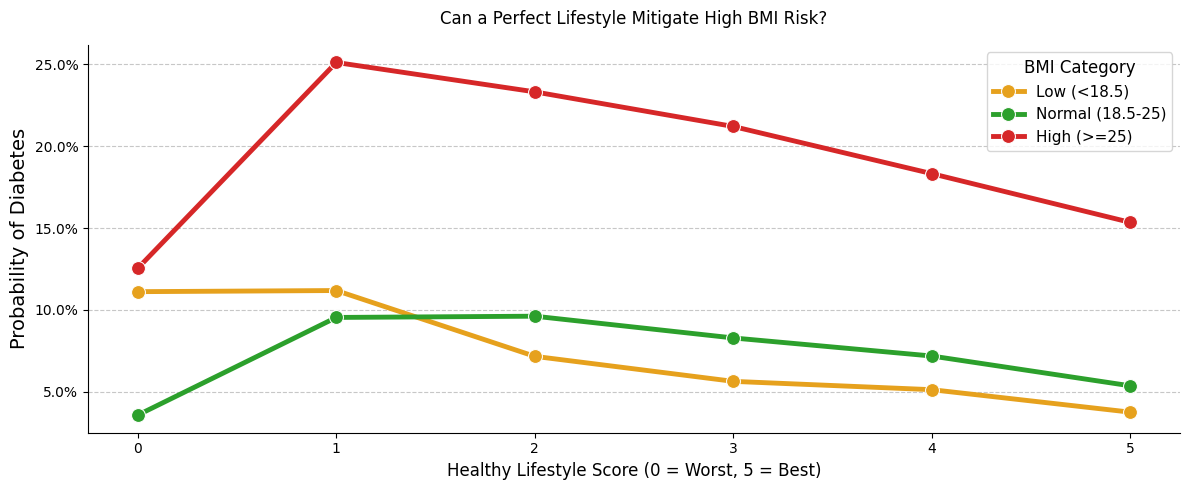

In [27]:
import matplotlib.ticker as mtick

data['Non_Smoker'] = 1 - data['Smoker']
data['Moderate_Alcohol'] = 1 - data['HvyAlcoholConsump']
data['Lifestyle_Score'] = data['PhysActivity'] + data['Fruits'] + data['Veggies'] + data['Non_Smoker'] + data['Moderate_Alcohol']

plt.figure(figsize=(12, 5))

ax = sns.lineplot(
    data=data, 
    x='Lifestyle_Score', 
    y='Diabetes_binary', 
    hue='BMI_cat_3', 
    palette=["#E6A11D", "#2CA02C", "#D62728"],
    marker="o",
    markersize=10,
    linewidth=3.5,
    errorbar=None
)

plt.title('Can a Perfect Lifestyle Mitigate High BMI Risk?', fontsize=12, pad=15)
plt.xlabel('Healthy Lifestyle Score (0 = Worst, 5 = Best)', fontsize=12)
plt.ylabel('Probability of Diabetes', fontsize=14)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.legend(title='BMI Category', title_fontsize=12, fontsize=11, 
           loc='upper right', frameon=True)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.grid(axis='x', alpha=0.0)

sns.despine()

plt.tight_layout()
plt.show()

This analysis demonstrates that a healthy lifestyle score reduces diabetes risk across all groups but fails to fully mitigate the impact of a high BMI. High-BMI individuals with perfect habits still face higher risks than normal-weight individuals with poor habits, confirming BMI as the primary driver of metabolic health.

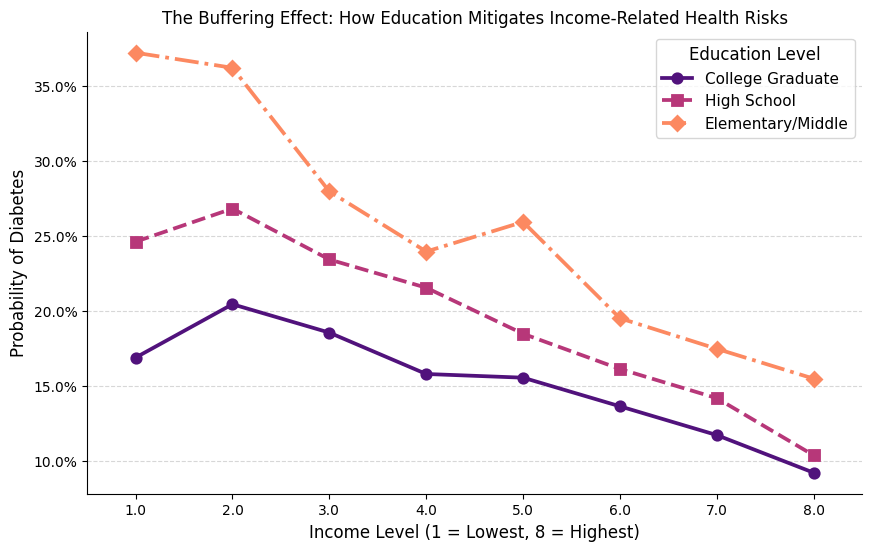

In [28]:
subset_edu = data[data['Education'].isin([2, 4, 6])].copy()

edu_map = {2: 'Elementary/Middle', 4: 'High School', 6: 'College Graduate'}
subset_edu['Education_Label'] = subset_edu['Education'].map(edu_map)

plt.figure(figsize=(10, 6))
ax = sns.pointplot(data=subset_edu, x='Income', y='Diabetes_binary', 
                   hue='Education_Label', errorbar=None, 
                   palette="magma", markers=["o", "s", "D"], linestyles=["-", "--", "-."])

plt.title('The Buffering Effect: How Education Mitigates Income-Related Health Risks', fontsize=12)
plt.xlabel('Income Level (1 = Lowest, 8 = Highest)', fontsize=12)
plt.ylabel('Probability of Diabetes', fontsize=12)

import matplotlib.ticker as mtick
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.legend(title='Education Level', fontsize=11, title_fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine()
plt.show()

This visualization reveals the powerful 'Buffering Effect' of education on health inequality. At the lowest income levels, we observe a massive gap: college graduates (Level 6) face nearly 50% lower risk than those with only elementary education (Level 2), despite having the same economic constraints. Education acts as a cognitive shield against the hazards of poverty. However, as income reaches the top tier, these lines converge. This suggests that while high income eventually equalizes health outcomes, education is the critical life-jacket that prevents chronic disease for those still climbing the socioeconomic ladder.

### BMI and age interaction
BMI and age are both important predictors individually, but their joint pattern is often more informative. This heatmap shows how diabetes prevalence changes across BMI groups and age groups at the same time.

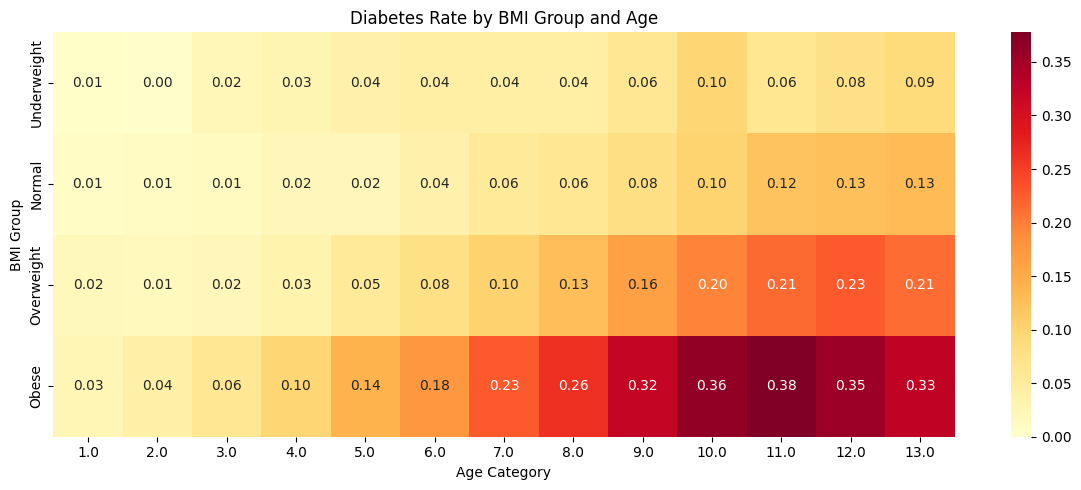

In [ ]:
bmi_age_df = data.copy()

bmi_age_df['BMI_Group'] = pd.cut(
    bmi_age_df['BMI'],
    bins=[0, 18.5, 25, 30, 100],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese'],
    include_lowest=True
)

bmi_age_pivot = bmi_age_df.pivot_table(
    values='Diabetes_binary',
    index='BMI_Group',
    columns='Age',
    aggfunc='mean'
)

plt.figure(figsize=(12, 5))
sns.heatmap(bmi_age_pivot, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title('Diabetes Rate by BMI Group and Age')
plt.xlabel('Age Category')
plt.ylabel('BMI Group')
plt.tight_layout()
plt.show()

This interaction view is more informative than separate BMI or age plots. In general, diabetes prevalence rises across both dimensions, and the highest risk is concentrated among older individuals in the overweight and obese groups.

### Relative risk lift across binary health indicators
Simple correlation does not always show how much risk changes in practical terms. Here, we compare diabetes prevalence between the 0 and 1 groups for several binary health indicators and compute the absolute increase in prevalence.

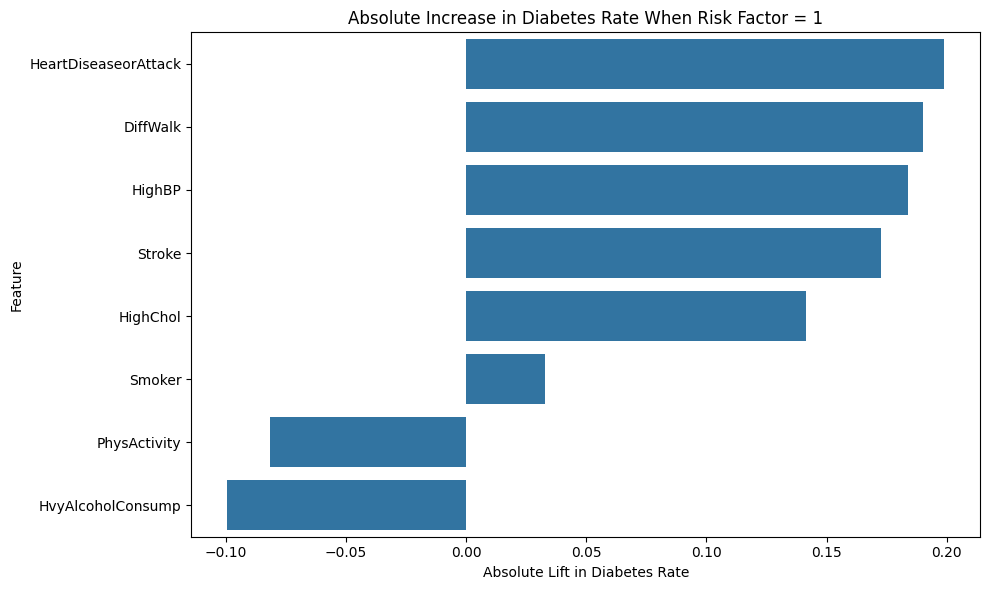

,Feature,Rate_if_0,Rate_if_1,Absolute_Lift
3,HeartDiseaseorAttack,0.132391,0.331295,0.198904
4,DiffWalk,0.117651,0.307660,0.190009
0,HighBP,0.069417,0.253261,0.183844
2,Stroke,0.145212,0.317775,0.172563
1,HighChol,0.090542,0.231842,0.141300
6,Smoker,0.137651,0.170485,0.032834
5,PhysActivity,0.212831,0.131137,-0.081694
7,HvyAlcoholConsump,0.158985,0.059642,-0.099343


In [37]:
binary_features = [
    'HighBP', 'HighChol', 'Stroke', 'HeartDiseaseorAttack',
    'DiffWalk', 'PhysActivity', 'Smoker', 'HvyAlcoholConsump'
]

risk_lift = []

for col in binary_features:
    temp = data.groupby(col)['Diabetes_binary'].mean()
    if 0 in temp.index and 1 in temp.index:
        risk_lift.append({
            'Feature': col,
            'Rate_if_0': temp.loc[0],
            'Rate_if_1': temp.loc[1],
            'Absolute_Lift': temp.loc[1] - temp.loc[0]
        })

risk_lift_df = pd.DataFrame(risk_lift).sort_values('Absolute_Lift', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=risk_lift_df, x='Absolute_Lift', y='Feature')
plt.title('Absolute Increase in Diabetes Rate When Risk Factor = 1')
plt.xlabel('Absolute Lift in Diabetes Rate')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

risk_lift_df

This plot gives a more interpretable ranking of binary predictors than a standard correlation chart. Features with the largest lift are likely to be especially useful in classification because they separate low-risk and high-risk groups more clearly.

 ## Income trend and diabetes prevalence
Income is an ordered socioeconomic indicator, so a trend-based view is more informative than a simple count plot. The following figure shows how diabetes prevalence changes across income levels.

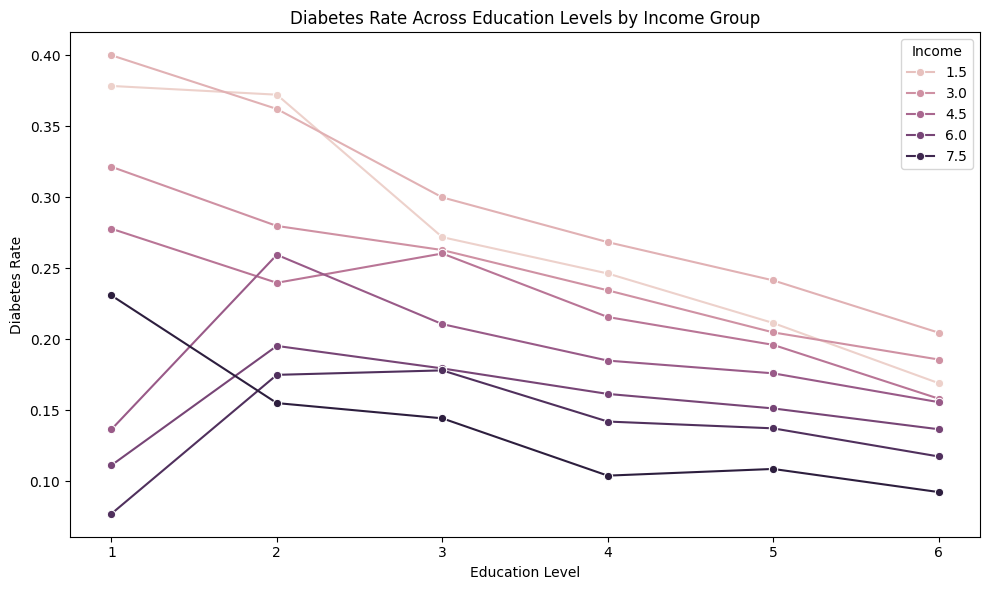

In [39]:
edu_income_trend = data.groupby(['Education', 'Income'])['Diabetes_binary'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=edu_income_trend,
    x='Education',
    y='Diabetes_binary',
    hue='Income',
    marker='o'
)

plt.title('Diabetes Rate Across Education Levels by Income Group')
plt.xlabel('Education Level')
plt.ylabel('Diabetes Rate')
plt.tight_layout()
plt.show()

The trend suggests that diabetes prevalence changes systematically across income categories, indicating that income may carry predictive value beyond purely medical variables.

# Model

### Dealing with imbalancing

In [ ]:
col1=['Diabetes_binary','HighBP', 'HighChol', 'BMI', 'Stroke', 'HeartDiseaseorAttack',  'GenHlth',
       'PhysHlth',  'DiffWalk','Age','PhysActivity','Education','Income']
data1=data[col1]


In [ ]:
X=data1.drop("Diabetes_binary",axis=1)
Y=data1["Diabetes_binary"]

In [ ]:
from imblearn.under_sampling import NearMiss
nm = NearMiss(version = 1 , n_neighbors = 10)

x_sm,y_sm= nm.fit_resample(X,Y)

In [ ]:
y_sm.shape , x_sm.shape

In [ ]:
y_sm.value_counts()

### split dataset

In [ ]:
from sklearn.model_selection import train_test_split
X_train , X_test , Y_train , Y_test = train_test_split(x_sm,y_sm, test_size=0.3 , random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()
X_train = scalar.fit_transform(X_train)
X_test = scalar.transform(X_test)

### logistic regression

In [ ]:
from sklearn.linear_model import LogisticRegression

lg = LogisticRegression()
lg.fit(X_train , Y_train)

In [ ]:
from sklearn.metrics import classification_report

y_pred=lg.predict(X_test)
matrix = classification_report(Y_test,y_pred )
print(matrix)

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm1 = confusion_matrix(Y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['True 0', 'True 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()
